In [ ]:
!pip install opencv-python matplotlib numpy

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving coral4.jpg to coral4.jpg
Saving coral3.jpg to coral3.jpg


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'coral4.jpg', 'coral3.jpg', 'sample_data']


Please upload your BEFORE and AFTER coral images.


Saving coral4.jpg to coral4 (2).jpg
Saving coral3.jpg to coral3 (2).jpg

Uploaded files:
   - coral4 (2).jpg
   - coral3 (2).jpg

CORAL ANALYSIS

Uploaded images:
0: coral4 (2).jpg
1: coral3 (2).jpg

Analyzing: coral3.jpg vs coral4.jpg

Loading images...
Aligning AFTER image with BEFORE...
Segmenting and classifying coral...
Comparing BEFORE vs AFTER...
Creating visualization...

RESULTS
---------------------------------------------
coral_area_before_%      :  24.51%
coral_area_after_%       :  24.70%
growth_%                 :   1.22%
damage_%                 :   0.92%
new_bleaching_%          :   1.31%
recovery_%               :   1.00%
still_healthy_%          :  18.07%
still_bleached_%         :   2.08%
---------------------------------------------

Result saved to:
/content/outputs/comparison_coral3_vs_coral4.png

Displaying final result...


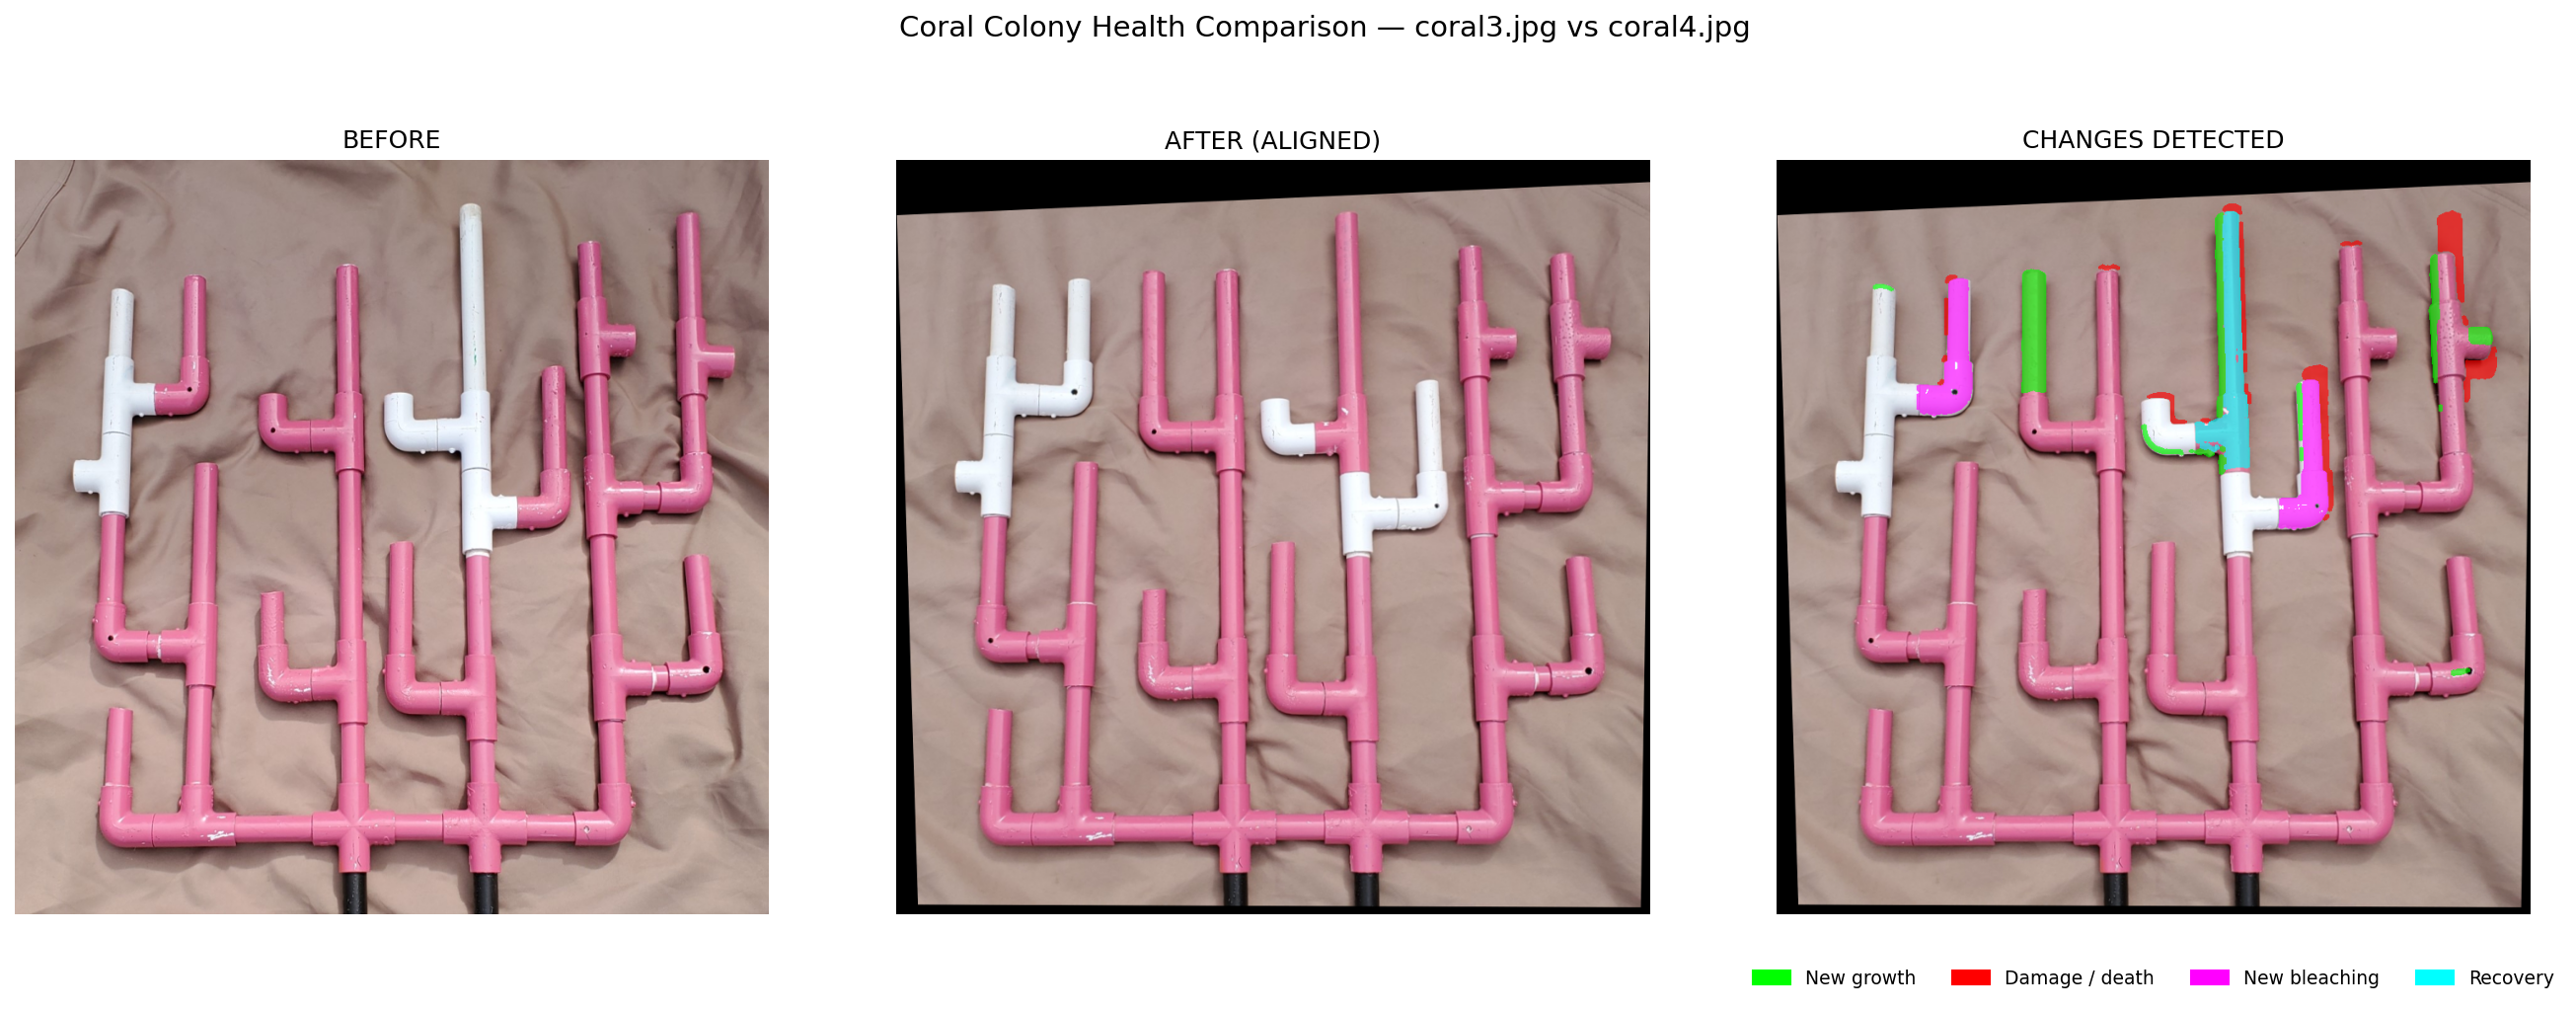


DONE!


In [ ]:
# ==============================================================================
# CORAL COLONY HEALTH ANALYSIS
# 1. IMPORT LIBRARIES
# ==============================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

from google.colab import files
from IPython.display import Image, display


# ==============================================================================
# 2. CONFIGURATION
# ==============================================================================

# Standard image size
STD_SIZE = (900, 900)

# ------------------------------------------------------------------------------
# Pink / Healthy Coral
# ------------------------------------------------------------------------------

PINK_HUE_MIN = 105
PINK_HUE_MAX = 178
PINK_SAT_MIN = 55

# ------------------------------------------------------------------------------
# White / Bleached Coral
# ------------------------------------------------------------------------------

WHITE_SAT_MAX = 30
WHITE_VALUE_MIN = 185

# ------------------------------------------------------------------------------
# Morphology
# ------------------------------------------------------------------------------

MORPH_KERNEL_SIZE = 5

# Minimum connected component size
MIN_BLOB_AREA = 40


# ==============================================================================
# 3. UPLOAD IMAGES
# ==============================================================================

print("Please upload your BEFORE and AFTER coral images.")

uploaded = files.upload()

print("\nUploaded files:")

for filename in uploaded.keys():
    print("   -", filename)


# ==============================================================================
# 4. CREATE OUTPUT FOLDER
# ==============================================================================

input_dir = "/content"
output_dir = "/content/outputs"

os.makedirs(output_dir, exist_ok=True)


# ==============================================================================
# 5. LOAD IMAGE
# ==============================================================================

def load_image(path):
    """
    Load an image from disk and resize it to STD_SIZE.
    """

    img = cv2.imread(path)

    if img is None:
        raise FileNotFoundError(
            f"Could not read image: {path}"
        )

    img = cv2.resize(
        img,
        STD_SIZE,
        interpolation=cv2.INTER_AREA
    )

    return img


# ==============================================================================
# 6. ALIGN IMAGES
# ==============================================================================

def align_images(
    img_to_warp,
    img_reference,
    max_features=2000,
    good_match_pct=0.15
):
    """
    Align the AFTER image with the BEFORE image using:

        ORB
        Feature Matching
        RANSAC
        Homography
        Perspective Warp
    """

    # Convert images to grayscale
    gray1 = cv2.cvtColor(
        img_to_warp,
        cv2.COLOR_BGR2GRAY
    )

    gray2 = cv2.cvtColor(
        img_reference,
        cv2.COLOR_BGR2GRAY
    )

    # Create ORB detector
    orb = cv2.ORB_create(max_features)

    # Detect features
    kp1, des1 = orb.detectAndCompute(
        gray1,
        None
    )

    kp2, des2 = orb.detectAndCompute(
        gray2,
        None
    )

    # Check if enough features exist
    if (
        des1 is None
        or des2 is None
        or len(kp1) < 10
        or len(kp2) < 10
    ):

        print("Not enough features detected.")
        print("Skipping alignment.")

        return (
            img_to_warp.copy(),
            np.eye(3)
        )

    # Feature matcher
    matcher = cv2.BFMatcher(
        cv2.NORM_HAMMING,
        crossCheck=True
    )

    # Match descriptors
    matches = matcher.match(
        des1,
        des2
    )

    # Sort matches by quality
    matches = sorted(
        matches,
        key=lambda m: m.distance
    )

    # Keep best matches
    num_good = max(
        int(len(matches) * good_match_pct),
        10
    )

    good_matches = matches[:num_good]

    if len(good_matches) < 4:

        print("Not enough good matches.")
        print("Skipping alignment.")

        return (
            img_to_warp.copy(),
            np.eye(3)
        )

    # Get matching points
    pts1 = np.float32(
        [
            kp1[m.queryIdx].pt
            for m in good_matches
        ]
    ).reshape(-1, 1, 2)

    pts2 = np.float32(
        [
            kp2[m.trainIdx].pt
            for m in good_matches
        ]
    ).reshape(-1, 1, 2)

    # Estimate homography using RANSAC
    homography, mask = cv2.findHomography(
        pts1,
        pts2,
        cv2.RANSAC,
        5.0
    )

    if homography is None:

        print("Homography estimation failed.")
        print("Skipping alignment.")

        return (
            img_to_warp.copy(),
            np.eye(3)
        )

    # Image dimensions
    h, w = img_reference.shape[:2]

    # Warp AFTER image
    aligned = cv2.warpPerspective(
        img_to_warp,
        homography,
        (w, h)
    )

    return aligned, homography


# ==============================================================================
# 7. REMOVE SMALL BLOBS
# ==============================================================================

def _remove_small_blobs(
    mask,
    min_area
):
    """
    Remove small connected components
    that are probably noise.
    """

    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )
    )

    cleaned = np.zeros_like(mask)

    for label in range(
        1,
        num_labels
    ):

        area = stats[
            label,
            cv2.CC_STAT_AREA
        ]

        if area >= min_area:

            cleaned[
                labels == label
            ] = 255

    return cleaned


# ==============================================================================
# 8. SEGMENT AND CLASSIFY CORAL
# ==============================================================================

def segment_and_classify(
    img_bgr
):
    """
    Detect coral pixels and classify them as:

        Pink  = Healthy
        White = Bleached
    """

    # Convert BGR to HSV
    hsv = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2HSV
    )

    # Split HSV channels
    h, s, v = cv2.split(hsv)

    # Detect pink / healthy coral
    pink_mask = (
        (h >= PINK_HUE_MIN)
        &
        (h <= PINK_HUE_MAX)
        &
        (s >= PINK_SAT_MIN)
    ).astype(np.uint8) * 255

    # Detect white / bleached coral
    white_mask = (
        (s <= WHITE_SAT_MAX)
        &
        (v >= WHITE_VALUE_MIN)
    ).astype(np.uint8) * 255

    # Combine pink and white
    coral_mask = cv2.bitwise_or(
        pink_mask,
        white_mask
    )

    # Morphological cleaning
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (
            MORPH_KERNEL_SIZE,
            MORPH_KERNEL_SIZE
        )
    )

    # Remove small noise
    coral_mask = cv2.morphologyEx(
        coral_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    # Fill small holes
    coral_mask = cv2.morphologyEx(
        coral_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Remove small components
    coral_mask = _remove_small_blobs(
        coral_mask,
        MIN_BLOB_AREA
    )

    # Restrict pink / white to coral region
    pink_mask = cv2.bitwise_and(
        pink_mask,
        coral_mask
    )

    white_mask = cv2.bitwise_and(
        white_mask,
        coral_mask
    )

    return (
        coral_mask,
        pink_mask,
        white_mask
    )


# ==============================================================================
# 9. COMPARE BEFORE VS AFTER
# ==============================================================================

def compare_health(
    coral_before,
    pink_before,
    white_before,
    coral_after,
    pink_after,
    white_after
):
    """
    Compare the two images pixel-by-pixel.

    Detect:

        Growth
        Damage
        Bleaching
        Recovery
        Still Healthy
        Still Bleached
    """

    # Morphological kernel
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (
            MORPH_KERNEL_SIZE,
            MORPH_KERNEL_SIZE
        )
    )

    # Small cleaning function
    def clean(mask):

        return cv2.morphologyEx(
            mask,
            cv2.MORPH_OPEN,
            kernel
        )

    # Pixels with no coral
    no_coral_before = cv2.bitwise_not(
        coral_before
    )

    no_coral_after = cv2.bitwise_not(
        coral_after
    )

    # Growth:
    # No coral BEFORE + Coral AFTER
    growth_mask = clean(
        cv2.bitwise_and(
            no_coral_before,
            coral_after
        )
    )

    # Damage:
    # Coral BEFORE + No coral AFTER
    damage_mask = clean(
        cv2.bitwise_and(
            coral_before,
            no_coral_after
        )
    )

    # New bleaching:
    # Pink BEFORE + White AFTER
    bleach_mask = clean(
        cv2.bitwise_and(
            pink_before,
            white_after
        )
    )

    # Recovery:
    # White BEFORE + Pink AFTER
    recovery_mask = clean(
        cv2.bitwise_and(
            white_before,
            pink_after
        )
    )

    # Still healthy:
    # Pink BEFORE + Pink AFTER
    still_healthy = clean(
        cv2.bitwise_and(
            pink_before,
            pink_after
        )
    )

    # Still bleached:
    # White BEFORE + White AFTER
    still_bleached = clean(
        cv2.bitwise_and(
            white_before,
            white_after
        )
    )

    # Remove tiny blobs from change masks
    growth_mask = _remove_small_blobs(
        growth_mask,
        MIN_BLOB_AREA
    )

    damage_mask = _remove_small_blobs(
        damage_mask,
        MIN_BLOB_AREA
    )

    bleach_mask = _remove_small_blobs(
        bleach_mask,
        MIN_BLOB_AREA
    )

    recovery_mask = _remove_small_blobs(
        recovery_mask,
        MIN_BLOB_AREA
    )

    # Create Region Of Interest
    roi_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (25, 25)
    )

    roi = cv2.bitwise_or(
        coral_before,
        coral_after
    )

    roi = cv2.dilate(
        roi,
        roi_kernel
    )

    # Restrict changes to coral region
    growth_mask = cv2.bitwise_and(
        growth_mask,
        roi
    )

    damage_mask = cv2.bitwise_and(
        damage_mask,
        roi
    )

    bleach_mask = cv2.bitwise_and(
        bleach_mask,
        roi
    )

    recovery_mask = cv2.bitwise_and(
        recovery_mask,
        roi
    )

    # Calculate statistics
    total_px = coral_before.size

    def pct(mask):

        return (
            100.0
            * np.count_nonzero(mask)
            / total_px
        )

    stats = {

        "coral_area_before_%":
            pct(coral_before),

        "coral_area_after_%":
            pct(coral_after),

        "growth_%":
            pct(growth_mask),

        "damage_%":
            pct(damage_mask),

        "new_bleaching_%":
            pct(bleach_mask),

        "recovery_%":
            pct(recovery_mask),

        "still_healthy_%":
            pct(still_healthy),

        "still_bleached_%":
            pct(still_bleached)
    }

    # Store masks
    masks = {

        "growth":
            growth_mask,

        "damage":
            damage_mask,

        "bleach":
            bleach_mask,

        "recovery":
            recovery_mask,

        "still_healthy":
            still_healthy,

        "still_bleached":
            still_bleached
    }

    return masks, stats


# ==============================================================================
# 10. COLORS FOR VISUALIZATION
# ==============================================================================

# OpenCV uses BGR

COLOR_GROWTH = (
    0,
    255,
    0
)

COLOR_DAMAGE = (
    0,
    0,
    255
)

COLOR_BLEACH = (
    255,
    0,
    255
)

COLOR_RECOVERY = (
    255,
    255,
    0
)


# ==============================================================================
# 11. CREATE CHANGE OVERLAY
# ==============================================================================

def make_overlay(
    base_img,
    masks
):
    """
    Draw detected changes on the image.
    """

    overlay = base_img.copy()

    highlight = np.zeros_like(
        base_img
    )

    # Growth -> Green
    highlight[
        masks["growth"] > 0
    ] = COLOR_GROWTH

    # Damage -> Red
    highlight[
        masks["damage"] > 0
    ] = COLOR_DAMAGE

    # Bleaching -> Magenta
    highlight[
        masks["bleach"] > 0
    ] = COLOR_BLEACH

    # Recovery -> Cyan
    highlight[
        masks["recovery"] > 0
    ] = COLOR_RECOVERY

    # Find changed pixels
    changed_area = (
        highlight.sum(axis=2) > 0
    )

    # Transparency
    alpha = 0.65

    overlay[
        changed_area
    ] = (
        alpha
        * highlight[changed_area]
        +
        (1 - alpha)
        * base_img[changed_area]
    ).astype(np.uint8)

    return overlay


# ==============================================================================
# 12. DRAW LEGEND
# ==============================================================================

def draw_legend(ax):

    legend_items = [

        (
            "New growth",
            np.array(
                COLOR_GROWTH[::-1]
            ) / 255.0
        ),

        (
            "Damage / death",
            np.array(
                COLOR_DAMAGE[::-1]
            ) / 255.0
        ),

        (
            "New bleaching",
            np.array(
                COLOR_BLEACH[::-1]
            ) / 255.0
        ),

        (
            "Recovery",
            np.array(
                COLOR_RECOVERY[::-1]
            ) / 255.0
        )
    ]

    handles = [
        plt.Rectangle(
            (0, 0),
            1,
            1,
            color=c
        )
        for _, c in legend_items
    ]

    labels = [
        name
        for name, _ in legend_items
    ]

    ax.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=4,
        frameon=False,
        fontsize=9
    )


# ==============================================================================
# 13. MAIN ANALYSIS FUNCTION
# ==============================================================================

def analyze_pair(
    before_path,
    after_path,
    output_path,
    pair_name=""
):

    print(
        f"\n{'=' * 70}"
    )

    print(
        f"Analyzing: {pair_name}"
    )

    print(
        f"{'=' * 70}"
    )

    # Load images
    print("\nLoading images...")

    img_before = load_image(
        before_path
    )

    img_after = load_image(
        after_path
    )

    # Align images
    print(
        "Aligning AFTER image with BEFORE..."
    )

    img_after_aligned, H = align_images(
        img_after,
        img_before
    )

    # Segment and classify
    print(
        "Segmenting and classifying coral..."
    )

    (
        coral_before,
        pink_before,
        white_before
    ) = segment_and_classify(
        img_before
    )

    (
        coral_after,
        pink_after,
        white_after
    ) = segment_and_classify(
        img_after_aligned
    )

    # Compare
    print(
        "Comparing BEFORE vs AFTER..."
    )

    masks, stats = compare_health(

        coral_before,
        pink_before,
        white_before,

        coral_after,
        pink_after,
        white_after
    )

    # Create overlay
    print(
        "Creating visualization..."
    )

    overlay = make_overlay(
        img_after_aligned,
        masks
    )

    # Create figure
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 7)
    )

    # BEFORE
    axes[0].imshow(
        cv2.cvtColor(
            img_before,
            cv2.COLOR_BGR2RGB
        )
    )

    axes[0].set_title(
        "BEFORE"
    )

    axes[0].axis("off")

    # AFTER
    axes[1].imshow(
        cv2.cvtColor(
            img_after_aligned,
            cv2.COLOR_BGR2RGB
        )
    )

    axes[1].set_title(
        "AFTER (ALIGNED)"
    )

    axes[1].axis("off")

    # CHANGES
    axes[2].imshow(
        cv2.cvtColor(
            overlay,
            cv2.COLOR_BGR2RGB
        )
    )

    axes[2].set_title(
        "CHANGES DETECTED"
    )

    axes[2].axis("off")

    draw_legend(
        axes[2]
    )

    fig.suptitle(
        f"Coral Colony Health Comparison — {pair_name}",
        fontsize=14
    )

    plt.tight_layout()

    # Save result
    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close(fig)

    # Print statistics
    print(
        "\nRESULTS"
    )

    print(
        "-" * 45
    )

    for key, value in stats.items():

        print(
            f"{key:25s}: {value:6.2f}%"
        )

    print(
        "-" * 45
    )

    print(
        f"\nResult saved to:\n{output_path}"
    )

    return stats


# ==============================================================================
# 14. SELECT BEFORE AND AFTER IMAGES
# ==============================================================================

print("\n" + "=" * 70)

print("CORAL ANALYSIS")

print("=" * 70)

print("\nUploaded images:")

image_files = [
    f
    for f in uploaded.keys()
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    )
]

for i, filename in enumerate(
    image_files
):

    print(
        f"{i}: {filename}"
    )


# ==============================================================================
# IMPORTANT:
# Change these two names if your uploaded images have different names.
# ==============================================================================

before_name = "coral3.jpg"
after_name = "coral4.jpg"


# ==============================================================================
# 15. CHECK FILES
# ==============================================================================

before_path = os.path.join(
    input_dir,
    before_name
)

after_path = os.path.join(
    input_dir,
    after_name
)

if not os.path.exists(
    before_path
):

    raise FileNotFoundError(
        f"BEFORE image not found: {before_name}\n"
        f"Please change 'before_name' to the correct uploaded filename."
    )

if not os.path.exists(
    after_path
):

    raise FileNotFoundError(
        f"AFTER image not found: {after_name}\n"
        f"Please change 'after_name' to the correct uploaded filename."
    )


# ==============================================================================
# 16. RUN ANALYSIS
# ==============================================================================

output_path = os.path.join(
    output_dir,
    f"comparison_{before_name.rsplit('.', 1)[0]}_vs_"
    f"{after_name.rsplit('.', 1)[0]}.png"
)

stats = analyze_pair(

    before_path,
    after_path,

    output_path,

    pair_name=
        f"{before_name} vs {after_name}"
)


# ==============================================================================
# 17. DISPLAY RESULT DIRECTLY IN COLAB
# ==============================================================================

print(
    "\nDisplaying final result..."
)

display(
    Image(
        filename=output_path
    )
)

print(
    "\nDONE!"
)